# Machine Learning Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<div class="alert alert-info">                  
<center><h1><b>SuperVised Learning</b></h1></center>
</div> 

<div class="alert alert-warning"><center><h2>Regression</h2></center></div>

<h3 class="alert alert-block alert-success">Linear Regression</h3>

In [4]:
data=pd.read_csv("income.csv")
print(f"data's shape = {data.shape}")
data.sample(2)

data's shape = (22, 3)


,Name,Age,Income($)
15,Ranbir,32,53000
14,Stark,29,49500


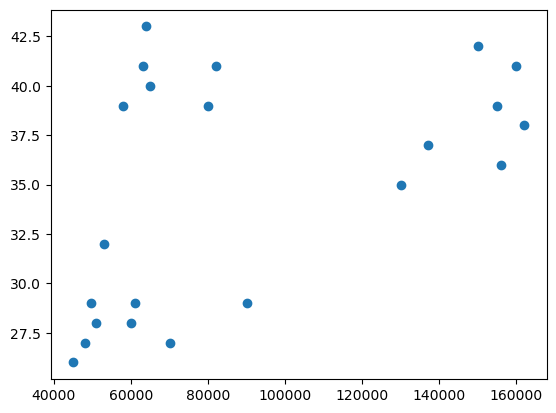

In [5]:
plt.scatter(x=data["Income($)"],y=data["Age"])

In [6]:
x=data.iloc[:,[1]]
y=data["Income($)"]

In [7]:
# scaling data
from sklearn.preprocessing import StandardScaler
Ss= StandardScaler()
x_scaled = Ss.fit_transform(x)

Text(0.5, 1.0, 'After')

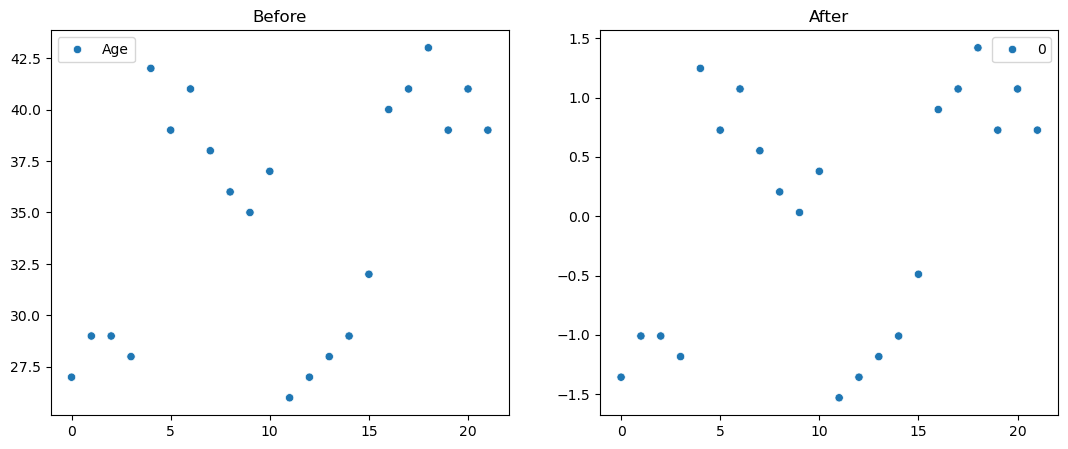

In [8]:
fig ,(ax1,ax2) = plt.subplots(ncols=2,figsize=(13,5))
sns.scatterplot(x,ax=ax1)
ax1.set_title("Before")
sns.scatterplot(x_scaled,ax=ax2)
ax2.set_title("After")

In [9]:
# traning model on old data
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)

LinearRegression()

In [10]:
# traning model on scaled data
from sklearn.linear_model import LinearRegression
lr_scaled = LinearRegression()
lr_scaled.fit(x_scaled,y)

LinearRegression()

In [11]:
print(f" old model = coff|{lr.coef_} , intercept|{lr.intercept_}")
print(f" new model = coff|{lr_scaled.coef_} , intercept|{lr_scaled.intercept_}")

 old model = coff|[3663.10293386] , intercept|-37110.76578816508
 new model = coff|[21119.20036768] , intercept|90431.81818181819


In [12]:
from sklearn.metrics import r2_score
print(f"old model accuracy = {r2_score(y,lr.predict(x))}")
print(f"new model accuracy = {r2_score(y,lr_scaled.predict(x_scaled))}")

old model accuracy = 0.24686568539181042
new model accuracy = 0.24686568539181042


**note**- the standard scaler has no effect on the simple linear regression

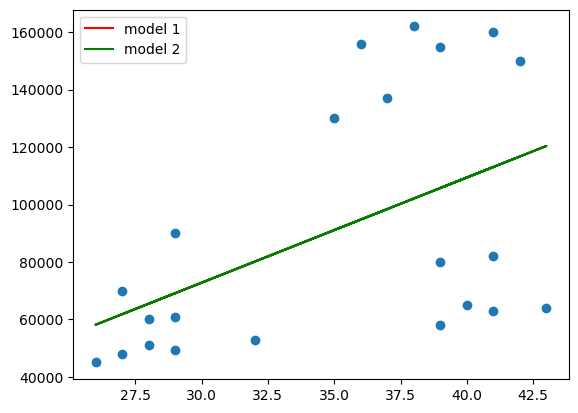

In [13]:
plt.scatter(x=data.iloc[:,[1]],y=data["Income($)"])
plt.plot(data.iloc[:,[1]],lr.predict(x),color="red",label="model 1")
plt.plot(data.iloc[:,[1]],lr_scaled.predict(x_scaled),color="green",label="model 2")
plt.legend()
plt.show()

<h3 class="alert alert-block alert-success">Multiple Linear Regression</h3>

In [14]:
data=pd.read_csv("homeprices.csv")
data.head(2)

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      9 non-null      int64  
 1   bedrooms  8 non-null      float64
 2   age       9 non-null      int64  
 3   price     9 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 420.0 bytes


In [16]:
mean = data["bedrooms"].mean()
data["bedrooms"] = data["bedrooms"].fillna(mean)

In [17]:
# seperating the veriables
x=data.iloc[:,:-1]
y=data.iloc[:,[-1]]
x

,area,bedrooms,age
0,2600,3.000,20
1,3000,4.000,15
2,3200,4.875,18
3,3600,3.000,30
4,4000,5.000,8
5,4100,6.000,8
6,4200,6.000,4
7,4300,6.000,7
8,4400,6.000,4


Text(0.5, 1.0, 'After')

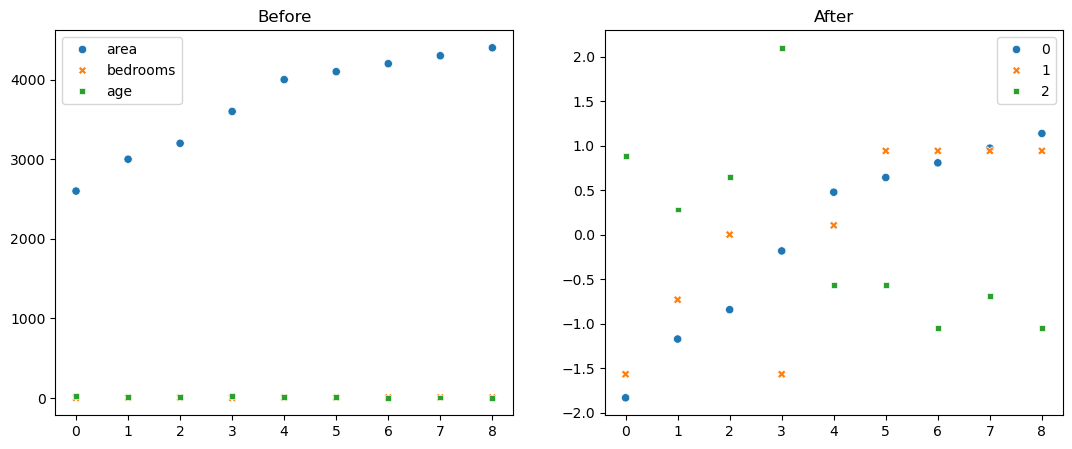

In [18]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_scaled = ss.fit_transform(x)

fig ,(ax1,ax2) = plt.subplots(ncols=2,figsize=(13,5))
sns.scatterplot(x,ax=ax1)
ax1.set_title("Before")
sns.scatterplot(x_scaled,ax=ax2)
ax2.set_title("After")

In [19]:
# making and training model with old data
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(x,y)

LinearRegression()

In [20]:
# making and training model with new data
from sklearn.linear_model import LinearRegression
mlr_scaler = LinearRegression()
mlr_scaler.fit(x_scaled,y)

LinearRegression()

In [21]:
from sklearn.metrics import r2_score
print(f"old model accuracy = {r2_score(y,mlr.predict(x))}")
print(f"new model accuracy = {r2_score(y,mlr_scaler.predict(x_scaled))}")

old model accuracy = 0.048401106145635864
new model accuracy = 0.048401106145635864


In [22]:
mlr.predict(x),mlr_scaler.predict(x_scaled)

(array([[554166.94873822],
        [594986.20075529],
        [707696.79156363],
        [592759.30912871],
        [584339.9343795 ],
        [688202.41290656],
        [645423.56480365],
        [667938.03449948],
        [634486.80322496]]),
 array([[554166.94873823],
        [594986.20075529],
        [707696.79156364],
        [592759.30912871],
        [584339.9343795 ],
        [688202.41290656],
        [645423.56480364],
        [667938.03449948],
        [634486.80322495]]))

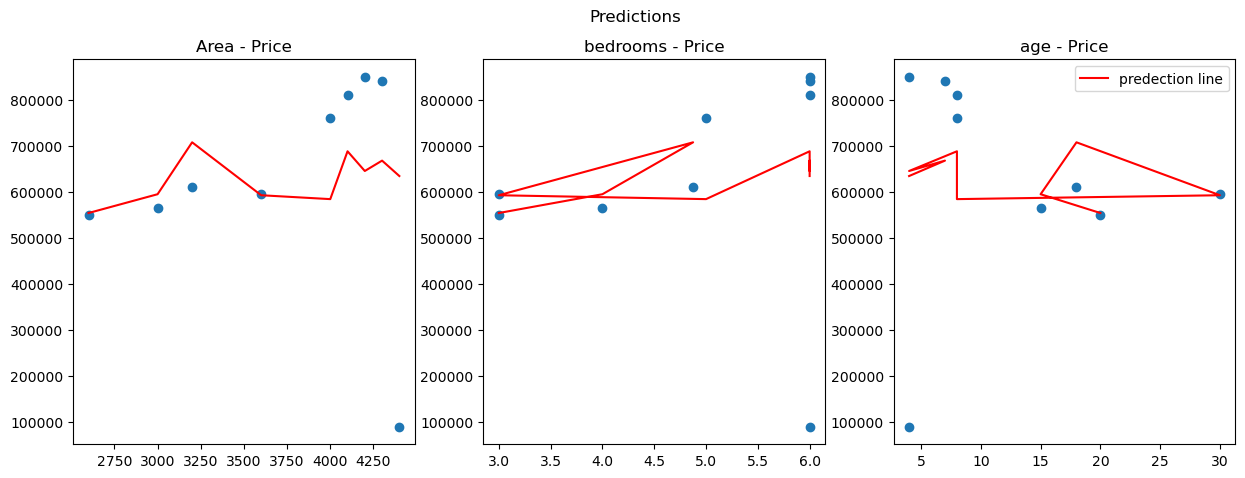

In [23]:
fig,ax = plt.subplots(ncols=3,figsize=(15,5))

ax[0].scatter(x=data["area"],y=data["price"])
ax[0].plot(data["area"],mlr.predict(x),color="red",label="predection line")
ax[0].set_title("Area - Price")

ax[1].scatter(x=data["bedrooms"],y=data["price"])
ax[1].plot(data["bedrooms"],mlr.predict(x),color="red",label="predection line")
ax[1].set_title("bedrooms - Price")

ax[2].scatter(x=data["age"],y=data["price"])
ax[2].plot(data["age"],mlr.predict(x),color="red",label="predection line")
ax[2].set_title("age - Price")

fig.suptitle("Predictions")
plt.legend()
plt.show()

<h3 class="alert alert-block alert-success">Polynomial Linear Regression</h3>

In [24]:
# useing the same data as above
x_scaled

array([[-1.83247329, -1.56764928,  0.88784774],
       [-1.17278291, -0.73156967,  0.28249701],
       [-0.84293771,  0.        ,  0.64570745],
       [-0.18324733, -1.56764928,  2.09854921],
       [ 0.47644306,  0.10450995, -0.56499402],
       [ 0.64136565,  0.94058957, -0.56499402],
       [ 0.80628825,  0.94058957, -1.04927461],
       [ 0.97121084,  0.94058957, -0.68606417],
       [ 1.13613344,  0.94058957, -1.04927461]])

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_scaled_poly = poly.fit_transform(x_scaled)
x_scaled_poly[:2]

array([[ 1.        , -1.83247329, -1.56764928,  0.88784774,  3.35795836,
         2.87267544, -1.62695728,  2.45752427, -1.39183388,  0.78827362],
       [ 1.        , -1.17278291, -0.73156967,  0.28249701,  1.37541974,
         0.8579724 , -0.33130766,  0.53519417, -0.20666624,  0.07980456]])

In [26]:
from sklearn.linear_model import LinearRegression
plr=LinearRegression()
plr.fit(x_scaled_poly,y)

LinearRegression()

In [27]:
from sklearn.metrics import r2_score
r2_score(y,plr.predict(x_scaled_poly))

1.0

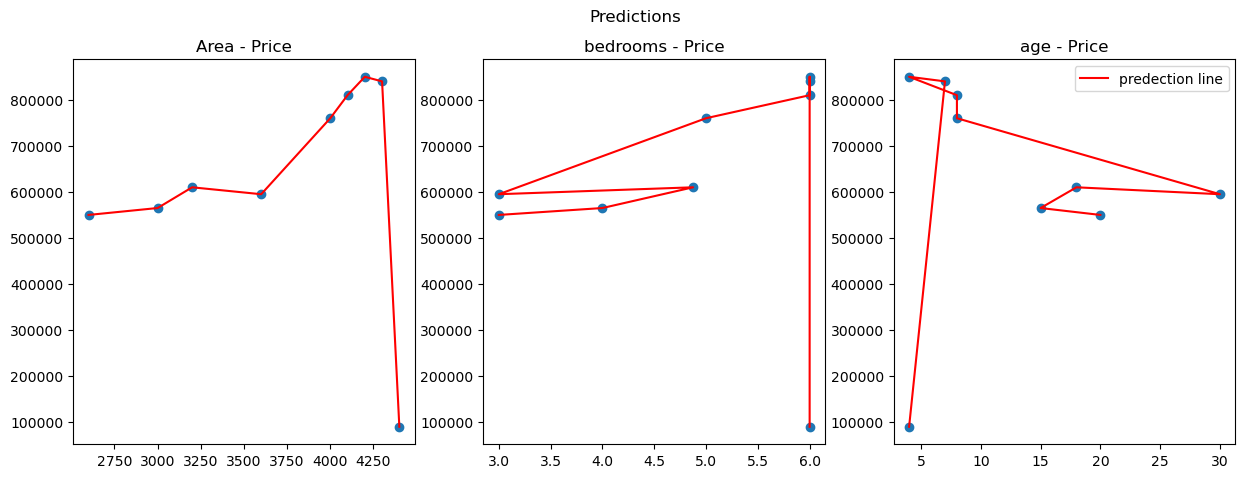

In [28]:
fig,ax = plt.subplots(ncols=3,figsize=(15,5))

ax[0].scatter(x=data["area"],y=data["price"])
ax[0].plot(data["area"],plr.predict(x_scaled_poly),color="red",label="predection line")
ax[0].set_title("Area - Price")

ax[1].scatter(x=data["bedrooms"],y=data["price"])
ax[1].plot(data["bedrooms"],plr.predict(x_scaled_poly),color="red",label="predection line")
ax[1].set_title("bedrooms - Price")

ax[2].scatter(x=data["age"],y=data["price"])
ax[2].plot(data["age"],plr.predict(x_scaled_poly),color="red",label="predection line")
ax[2].set_title("age - Price")

fig.suptitle("Predictions")
plt.legend()
plt.show()

<div class="alert alert-warning"><center><h2>Classification</h2></center></div>

<h3 class="alert alert-block alert-success">Logistic Regression</h3>

In [29]:
data=pd.read_csv("heart_attack_dataset.csv")
print(f"data shape = {data.shape}")
data.head(1)

data shape = (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

<Axes: xlabel='Heart Attack Risk', ylabel='Count'>

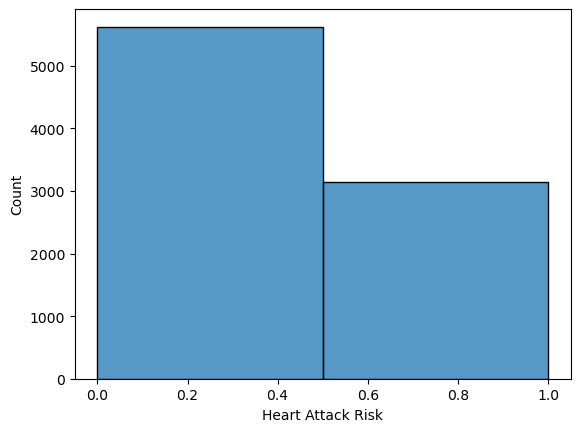

In [31]:
sns.histplot(data["Heart Attack Risk"],bins=2)

In [32]:
numerical_cols = [x for x in data.columns if data[x].dtype=="int64" or data[x].dtype=="float64"]
data = data[numerical_cols]
data.drop("Smoking",axis=1,inplace=True)
print(f"data shape ={data.shape}")
data.head(2)

data shape =(8763, 18)


,Age,Cholesterol,Heart Rate,Diabetes,Family History,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,208,72,0,0,0,0,4.168189,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,389,98,1,1,1,1,1.813242,1,0,1,4.963459,285768,27.194973,235,1,7,0


<Axes: >

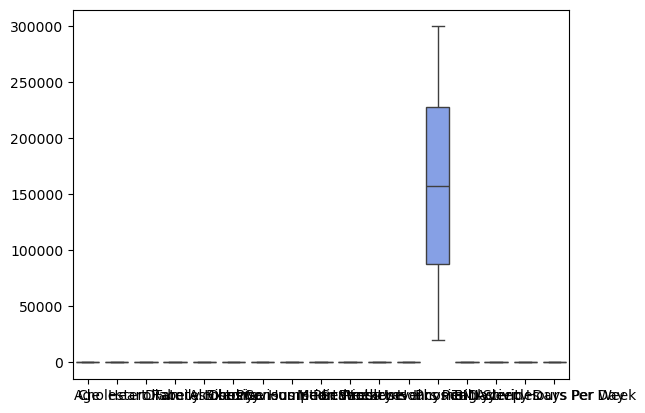

In [33]:
sns.boxplot(data.iloc[:,:-1])

In [34]:
x=data.iloc[:,:-1]
y=data["Heart Attack Risk"]

In [35]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_scaled = ss.fit_transform(x)

In [36]:
scaled_data = pd.DataFrame(x_scaled,columns=x.columns)
scaled_data.head(2)

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day
0,0.625557,-0.641579,-0.147042,-1.369651,-0.986061,-1.002857,-1.219867,-1.010838,-0.991704,-0.996696,1.234604,0.179251,1.280130,0.373454,-0.588539,-1.528843,-0.514750
1,-1.539322,1.596895,1.118179,0.730113,1.014136,0.997151,0.819762,-1.418027,1.008365,-0.996696,-1.563129,-0.297225,1.582523,-0.268479,-0.816487,-1.090738,-0.011823


<Axes: >

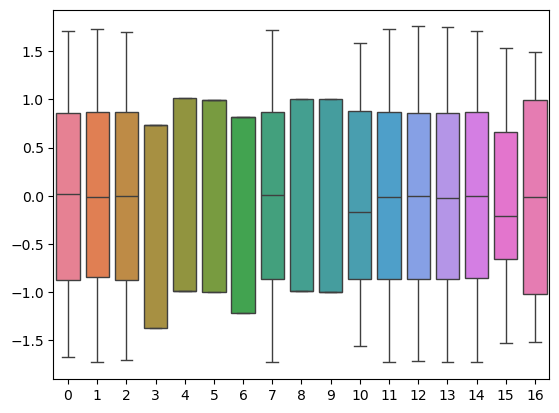

In [37]:
sns.boxplot(x_scaled)

In [38]:
# applying logastic regression on un scaled data
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000)
lr.fit(x,y)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

**As there is a large gap between the x veriable the model can not define a answer even after 5000 iteations**

In [39]:
# applying logastic regression on scaled data
from sklearn.linear_model import LogisticRegression
lr_scaled = LogisticRegression(class_weight='balanced',max_iter=1000)
lr_scaled.fit(x_scaled,y)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
lr.predict(x),lr_scaled.predict(x_scaled)

(array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
 array([1, 1, 1, ..., 0, 1, 1], dtype=int64))

In [41]:
# classification report for precision, recall f1-score and accuracy
from sklearn.metrics import classification_report
matrix = classification_report(y, lr.predict(x),labels=[1,0])

print('Classification report of non scaled model : \n',matrix)

Classification report of non scaled model : 
               precision    recall  f1-score   support

           1       0.00      0.00      0.00      3139
           0       0.64      1.00      0.78      5624

    accuracy                           0.64      8763
   macro avg       0.32      0.50      0.39      8763
weighted avg       0.41      0.64      0.50      8763



C:\Users\updes\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**it seems the the accuracy of the above model is higher but no as we can see that it never predict the value of 1 and this is exactly what the warning is telling that the model never predicts its just give the majority number as a result which was zero**

In [42]:
from sklearn.metrics import classification_report
matrix_scaled = classification_report(y, lr_scaled.predict(x_scaled),labels=[1,0])
print('Classification report of scaled model : \n',matrix_scaled)

Classification report of scaled model : 
               precision    recall  f1-score   support

           1       0.37      0.52      0.44      3139
           0       0.66      0.51      0.57      5624

    accuracy                           0.51      8763
   macro avg       0.51      0.52      0.50      8763
weighted avg       0.56      0.51      0.52      8763



<h3 class="alert alert-block alert-success">Naive Bayes</h3>

In [43]:
data = pd.read_csv("tennis-data.csv")
data.shape

(14, 5)

In [44]:
data.head(2)

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no


In [45]:
x=data.iloc[:,:-1]
y=data["play"]

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
data["play"] = le.transform(y)

In [47]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first",sparse_output=False)
x=ohe.fit_transform(x)

In [48]:
y=data["play"]
y,x

(0     0
 1     0
 2     1
 3     1
 4     1
 5     0
 6     1
 7     0
 8     1
 9     1
 10    1
 11    1
 12    1
 13    0
 Name: play, dtype: int32,
 array([[0., 1., 1., 0., 0., 0.],
        [0., 1., 1., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 1., 0., 1., 0., 0.],
        [0., 1., 0., 0., 1., 0.],
        [1., 0., 0., 1., 1., 0.],
        [0., 1., 0., 1., 1., 1.],
        [0., 0., 0., 1., 0., 1.],
        [0., 0., 1., 0., 1., 0.],
        [1., 0., 0., 1., 0., 1.]]))

In [49]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x,y)

GaussianNB()

In [50]:
ypred=gnb.predict(x)
ypred

array([0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0])

In [51]:
from sklearn.metrics import classification_report
matrix = classification_report(y, ypred,labels=[1,0])

print('Classification report of non scaled model : \n',matrix)

Classification report of non scaled model : 
               precision    recall  f1-score   support

           1       0.90      1.00      0.95         9
           0       1.00      0.80      0.89         5

    accuracy                           0.93        14
   macro avg       0.95      0.90      0.92        14
weighted avg       0.94      0.93      0.93        14



<div class="alert alert-warning"><center><h2>Both (Regression and Classification)</h2></center></div>

<h3 class="alert alert-block alert-success">(KNN) k Nearest Neighbores</h3>

In [52]:
data = pd.read_csv("heart_attack_dataset.csv")
data.shape

(8763, 26)

In [53]:
data.head(2)

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0


In [54]:
temp = data["Blood Pressure"].apply(lambda x: np.int64(x.split("/")))
data["systolicBP"] = [x[0]for x in temp]
data["diastolicBP"] = [x[1]for x in temp]
data.drop("Blood Pressure",axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null   object 
 12  Previous Heart Probl

In [55]:
data.drop("Patient ID",axis=1,inplace=True)
data.isnull().sum()

Age                                0
Sex                                0
Cholesterol                        0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
systolicBP                         0
diastolicBP                        0
dtype: int64

In [56]:
numerical_columns = [x for x in data.columns if data[x].dtype=="int64" or data[x].dtype=="float64"]
categorical_columns = [x for x in data.columns if data[x].dtype=="object"]
categorical_columns

['Sex', 'Diet', 'Country', 'Continent', 'Hemisphere']

In [57]:
data[categorical_columns].nunique()

Sex            2
Diet           3
Country       20
Continent      6
Hemisphere     2
dtype: int64

In [58]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first",sparse_output=False)
x=ohe.fit_transform(data[categorical_columns])
x.shape

(8763, 28)

In [59]:
y=data[numerical_columns.pop(-3)]

In [60]:
xtrain = np.hstack((x,data[numerical_columns].to_numpy()))
xtrain.shape

(8763, 48)

In [61]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski')
classifier.fit(xtrain,y)

KNeighborsClassifier(n_neighbors=3)

In [62]:
ypred=classifier.predict(xtrain)
ypred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [63]:
from sklearn.metrics import classification_report
matrix = classification_report(y, ypred,labels=[1,0])

print('Classification report of non scaled model : \n',matrix)

Classification report of non scaled model : 
               precision    recall  f1-score   support

           1       0.71      0.59      0.64      3139
           0       0.79      0.87      0.83      5624

    accuracy                           0.77      8763
   macro avg       0.75      0.73      0.73      8763
weighted avg       0.76      0.77      0.76      8763



<h3 class="alert alert-block alert-success">(SVM) Support Vector Machine</h3>

In [64]:
data = pd.read_csv("iris.csv")
data.shape

(150, 5)

In [65]:
data.sample(2)

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
106,4.9,2.5,4.5,1.7,virginica


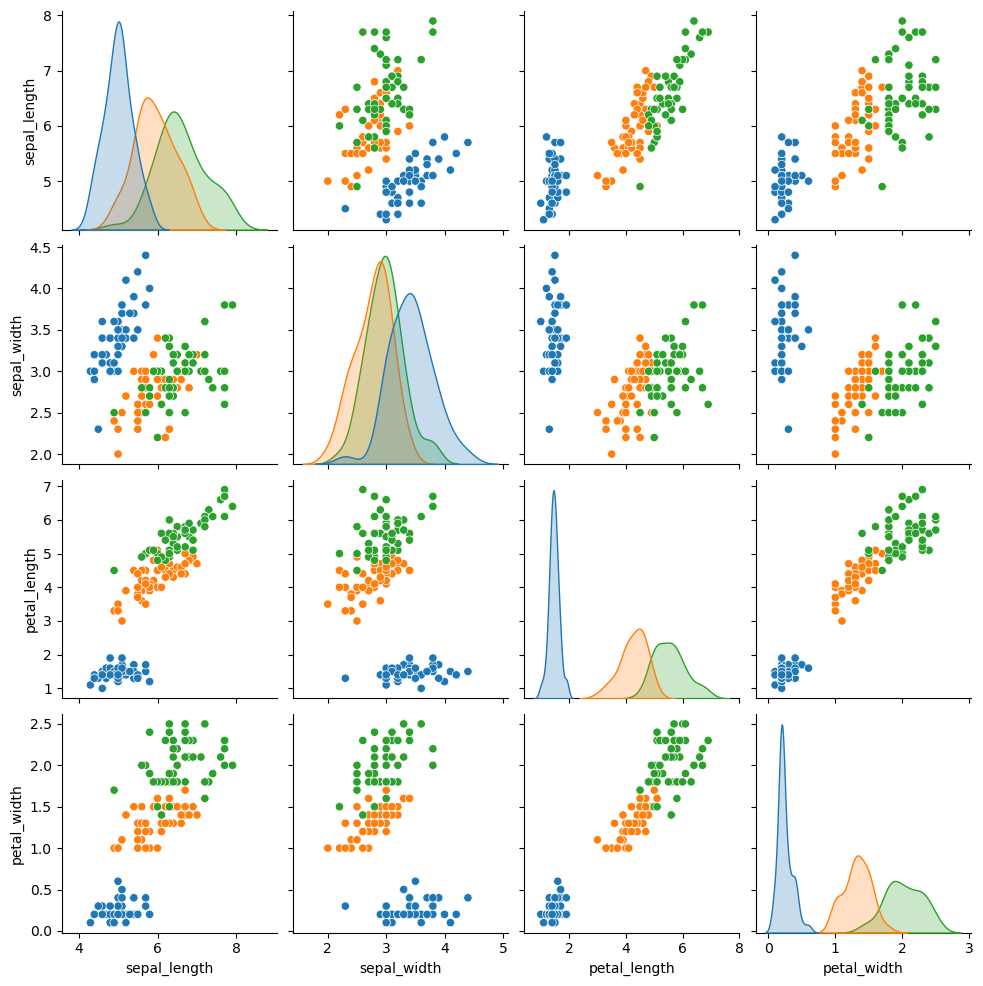

In [66]:
g = sns.pairplot(data=data,hue="species")
g._legend.remove()
plt.show()

In [67]:
data = data[data["species"]!="versicolor"]

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

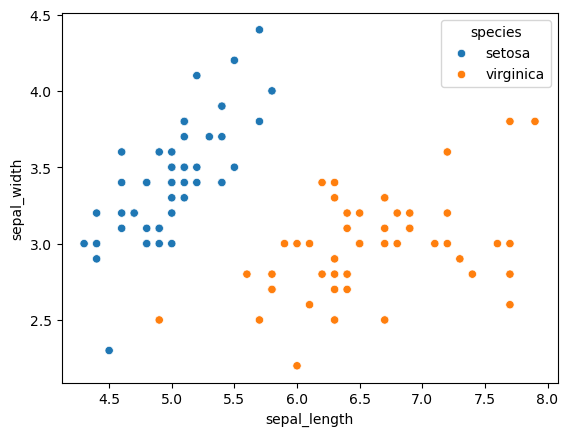

In [68]:
sns.scatterplot(x=data["sepal_length"],y=data["sepal_width"],hue=data["species"])

In [69]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["species"] = le.fit_transform(data["species"])
data.head()

C:\Users\updes\AppData\Local\Temp\ipykernel_9096\3042842925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["species"] = le.fit_transform(data["species"])


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [70]:
x=data.iloc[:,:2]
y=data.iloc[:,[-1]]
x.shape,y.shape

((100, 2), (100, 1))

In [71]:
from sklearn.svm import SVC
svc = SVC(kernel="linear",C=1)
svc.fit(x,y)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, kernel='linear')

In [72]:
ypred=svc.predict(x)
ypred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [73]:
from sklearn.metrics import classification_report
matrix = classification_report(y, ypred,labels=data["species"].unique())

print('Classification report of this model : \n',matrix)

Classification report of this model : 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.98      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


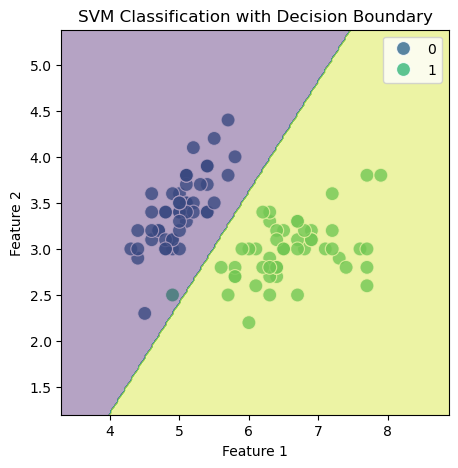

In [74]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=data["species"], palette='viridis', s=100, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Classification with Decision Boundary')

# Create a mesh to plot decision boundaries
x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1
y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Create a 4-feature input array for prediction on the mesh grid
# The first two columns are the grid points, the last two are the mean values
input_features = np.c_[
    xx.ravel(),
    yy.ravel(),
]

# Predict class labels for each point in the mesh
Z = svc.predict(input_features)
Z = Z.reshape(xx.shape)

# Plot the decision boundary as a filled contour
plt.contourf(xx, yy, Z, alpha=0.4,)

plt.legend()
plt.show()

In Support Vector Machines (SVMs), a classification error occurs when a **data point is on the wrong side of the separating hyperplane**, meaning the SVM incorrectly assigns it to a class  

models with different **classification error values**

In [75]:
from sklearn.svm import SVC
svc_C_01 = SVC(kernel="linear",C=0.01)
svc_C_1 = SVC(kernel="linear",C=1)
svc_C_100 = SVC(kernel="linear",C=100)

svc_C_01.fit(x,y)
svc_C_1.fit(x,y)
svc_C_100.fit(x,y)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=100, kernel='linear')

In [76]:
def decision_boundary_plot(x_data,y_data,model,axis=plt):
    x=x_data
    y=y_data
    svc=model
    sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=data["species"], palette='viridis', s=100, alpha=0.8,ax=axis)
    
    # Create a mesh to plot decision boundaries
    x_min, x_max = x.iloc[:, 0].min() - 1, x.iloc[:, 0].max() + 1
    y_min, y_max = x.iloc[:, 1].min() - 1, x.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Create a 4-feature input array for prediction on the mesh grid
    # The first two columns are the grid points, the last two are the mean values
    input_features = np.c_[
        xx.ravel(),
        yy.ravel(),
    ]
    
    # Predict class labels for each point in the mesh
    Z = svc.predict(input_features)
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary as a filled contour
    axis.contourf(xx, yy, Z, alpha=0.4,)
    axis.tick_params(labelbottom=False)
    axis.tick_params(labelleft=False)
    
    axis.legend()

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


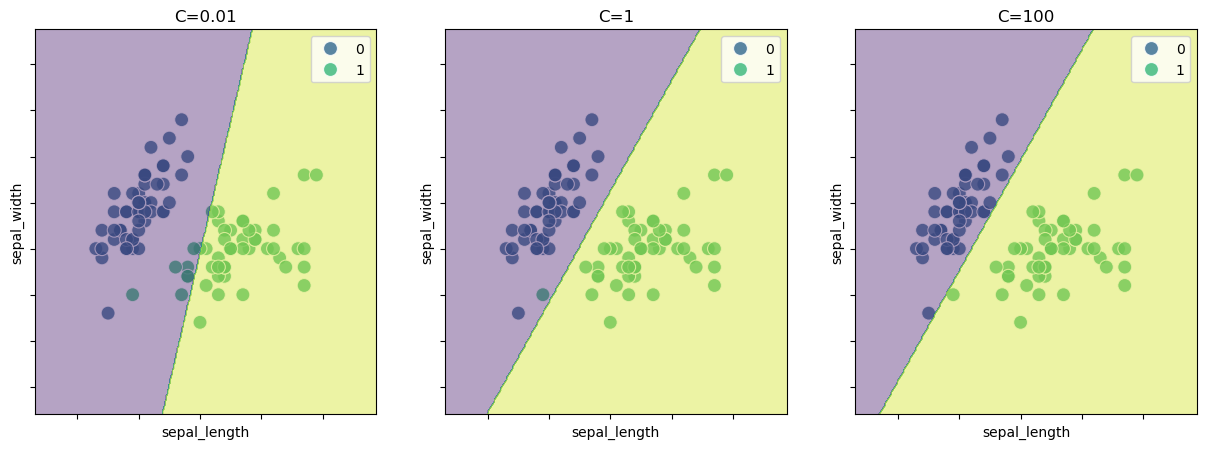

In [77]:
fig , (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,5))
decision_boundary_plot(x,y,svc_C_01,ax1)
ax1.set_title("C=0.01")

decision_boundary_plot(x,y,svc_C_1,ax2)
ax2.set_title("C=1")

decision_boundary_plot(x,y,svc_C_100,ax3)
ax3.set_title("C=100")

plt.show()

The kernel trick in Support Vector Machines (SVMs) is a mathematical method that **allows SVMs to classify non-linearly separable data by implicitly mapping it to a higher-dimensional feature** space where a linear hyperplane can separate the classes  
|kernal|usage|
|------|-----|
|**rbf**|. It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote|
|**linear**|The dot product of the two points determines the cosine_similarity between both points|
|**poly**|_polynomial kernel is equivalent to creating PolynomialFeatures and then fitting a SVC with a linear kernel on the transformed data_|
|**sigmoid**|the similarity between two data points is computed using the hyperbolic tangent function (tenH)|
|**precomputed**| where the kernel matrix (also known as the Gram matrix) is calculated before being passed to the SVM algorithm|

In [78]:
from sklearn.svm import SVC
svc_rba=SVC(kernel="rbf",C = 100)
svc_linear=SVC(kernel="linear",C = 100)
svc_poly=SVC(kernel="poly",C = 100)
svc_sigmoid=SVC(kernel="sigmoid",C = 100)

svc_rba.fit(x,y)
svc_linear.fit(x,y)
svc_poly.fit(x,y)
svc_sigmoid.fit(x,y)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

SVC(C=100, kernel='sigmoid')

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\updes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


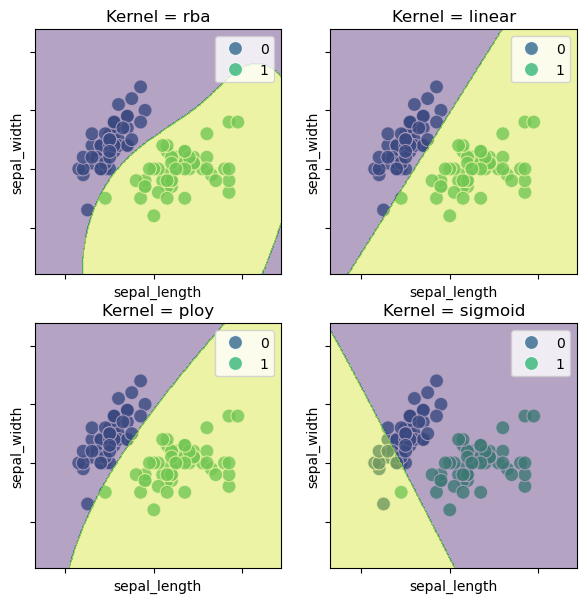

In [79]:
fig , ax = plt.subplots(nrows=2,ncols=2,figsize=(7,7))
decision_boundary_plot(x,y,svc_rba,ax[0,0])
ax[0,0].set_title("Kernel = rba")

decision_boundary_plot(x,y,svc_linear,ax[0,1])
ax[0,1].set_title("Kernel = linear")

decision_boundary_plot(x,y,svc_poly,ax[1,0])
ax[1,0].set_title("Kernel = ploy")

decision_boundary_plot(x,y,svc_sigmoid,ax[1,1])
ax[1,1].set_title("Kernel = sigmoid")

plt.show()

<h3 class="alert alert-block alert-success">Decision Tree</h3>

In [80]:
data = pd.read_csv("tennis-data.csv")
data.head(2)

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no


In [81]:
x=data.iloc[:,:-1]
y=data.iloc[:,[-1]]

In [82]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

ohe = OneHotEncoder(drop="first",sparse_output=False)
x_encoded = ohe.fit_transform(x)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [83]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(criterion="entropy")
dtc.fit(x_encoded,y_encoded)

DecisionTreeClassifier(criterion='entropy')

In [84]:
y_encoded

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [85]:
ypred = dtc.predict(x_encoded)
ypred

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

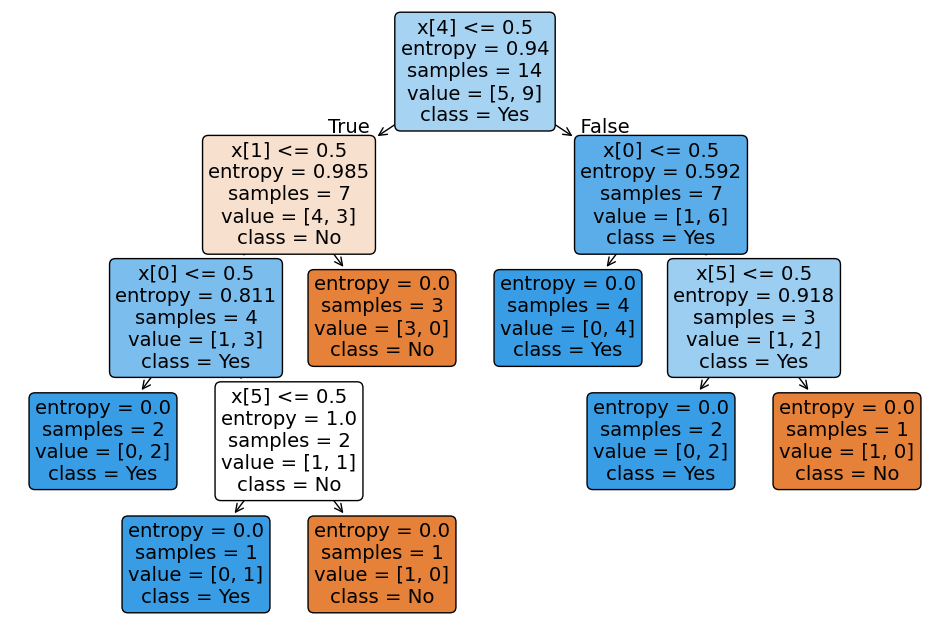

In [86]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(dtc, 
          class_names=['No', 'Yes'],
          filled=True, 
          rounded=True)
plt.show()

In [87]:
from sklearn.metrics import classification_report
matrix = classification_report(y_encoded, ypred,labels=[1,0])

print('Classification report of this model : \n',matrix)

Classification report of this model : 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         9
           0       1.00      1.00      1.00         5

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



<h3 class="alert alert-block alert-success">Random Forest</h3>

In [88]:
data = pd.read_csv("heart_attack_dataset.csv")
data.head(2)

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0


In [89]:
numerical_columns = [x for x in data.columns if data[x].dtype=="int64" or data[x].dtype=="float64"]
data[numerical_columns]

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,21,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,235282,28.176571,587,4,4,0
3,84,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,125640,36.464704,378,3,4,0
4,66,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,160555,21.809144,231,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,121,61,1,1,1,0,1,7.917342,1,1,8,10.806373,235420,19.655895,67,7,7,0
8759,28,120,73,1,0,0,1,0,16.558426,0,0,8,3.833038,217881,23.993866,617,4,9,0
8760,47,250,105,0,1,1,1,1,3.148438,1,0,5,2.375214,36998,35.406146,527,4,4,1
8761,36,178,60,1,0,1,0,0,3.789950,1,1,5,0.029104,209943,27.294020,114,2,8,0


In [90]:
y=data[numerical_columns.pop(-3)]
y

0       0
1       1
2       4
3       3
4       1
       ..
8758    7
8759    4
8760    4
8761    2
8762    7
Name: Physical Activity Days Per Week, Length: 8763, dtype: int64

In [91]:
x=data[numerical_columns]

In [92]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=5)
rfc.fit(x,y)

RandomForestClassifier(n_estimators=5)

In [93]:
ypred = rfc.predict(x)
ypred

array([0, 1, 4, ..., 4, 2, 7], dtype=int64)

In [94]:
from sklearn.metrics import classification_report
matrix = classification_report(y, rfc.predict(x),labels=y.unique())

print('Classification report of non scaled model : \n',matrix)

Classification report of non scaled model : 
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1065
           1       0.91      0.96      0.93      1121
           4       0.96      0.93      0.94      1077
           3       0.93      0.93      0.93      1143
           5       0.95      0.92      0.94      1079
           6       0.96      0.90      0.93      1074
           7       0.97      0.90      0.93      1095
           2       0.92      0.96      0.94      1109

    accuracy                           0.93      8763
   macro avg       0.93      0.93      0.93      8763
weighted avg       0.93      0.93      0.93      8763



<div class="alert alert-warning"><center><h2>Time Series Analysis</h2></center></div>

![](https://media.licdn.com/dms/image/v2/D4D12AQEyGYQwD4GuKw/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1692815066578?e=2147483647&v=beta&t=TLD31nDmpeZeOscTV7FYtXLPp7CUd4Znv2dFWmXK09A)

* _Time series analysis in machine learning is the analysis of sequential data points collected at regular time intervals to uncover **patterns, trends, and seasonality**, and to predict future outcomes based on historical data._ 

* _It involves decomposing the data into components like trend (long-term movement), seasonality (repeating patterns), and irregular fluctuations to **understand past behavior and forecast future values**._

![](https://media.geeksforgeeks.org/wp-content/uploads/20240329115620/Time-Series-Data-Charactersti.png)

#### STEPS
1. Visualize the Time Series Data
2. Identify if the date is stationary
3. Plot the Correlation and Auto Correlation Charts
4. Construct the ARIMA Model or Seasonal ARIMA based on the data

In [34]:
data=pd.read_csv("all_stocks_5yr.csv")
data.shape

(619040, 7)

In [35]:
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [36]:
data["Name"].value_counts()

Name
AAL     1259
NRG     1259
NOC     1259
NLSN    1259
NKE     1259
        ... 
DXC      215
BHGE     152
BHF      143
DWDP     109
APTV      44
Name: count, Length: 505, dtype: int64

Let's select the **AAL(American Airlines Group)** stock with data and high column

In [37]:
AAL = data[data["Name"]=="AAL"][["date","high"]]
AAL.isnull().sum()

date    0
high    0
dtype: int64

In [38]:
AAL.duplicated().sum()

0

In [39]:
AAL["date"] = pd.to_datetime(AAL["date"])
AAL.set_index("date",inplace=True)
AAL.head()

,high
date,
2013-02-08,15.12
2013-02-11,15.01
2013-02-12,14.51
2013-02-13,14.94
2013-02-14,14.96


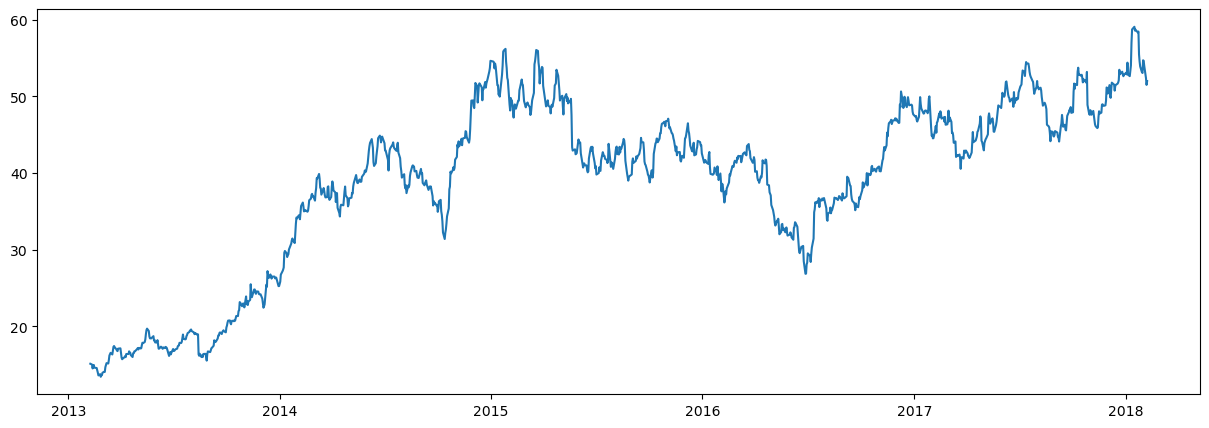

In [45]:
plt.figure(figsize=(15,5))
plt.plot(AAL)

if we see the above graph then we will able to find a trend that there is a time when sales are high and vice versa. That means we can see data is following seasonality. For ARIMA first thing we do is identify if the data is stationary or non – stationary. if data is non-stationary we will try to make them stationary then we will process further.

Let’s check that if the given dataset is stationary or not, For that we use adfuller.

In [46]:
from statsmodels.tsa.stattools import adfuller
def adfuller_test(Sales):
    result=adfuller(Sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )

    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data is stationary")
    else:
        print("weak evidence against null hypothesis,indicating it is non-stationary ")

adfuller_test(AAL['high'])

ADF Test Statistic : -2.039421087043984
p-value : 0.26956016092967783
#Lags Used : 1
Number of Observations : 1257
weak evidence against null hypothesis,indicating it is non-stationary 


**stationary time series**: A stationary time series implies that its statistical properties, such as the mean, variance, and autocorrelation, remain constant over time. This means that the underlying data-generating process is stable and does not change with the observation period.  

**non-stationary time series**: A non-stationary time series indicates that its statistical properties change over time. This could be due to the presence of trends, seasonality, or a changing variance.

#### As **p = 2.6** which is greater then 0.05 heance data is non-stationary Hence- trends, seasonality, or a changing variance.

<h3 class="alert alert-block alert-success">ARIMA (Autoregressive Integrated Moving Average)</h3>

**FORMULA:**
$$Y_t = c+\alpha_1Y_t-1+\alpha_2Y_t-2+.....+\alpha_nY_t-n+\beta$$

**steps:**  
  1. try to remove the seasonality from data
  2. Apply ARIMA

#### **Differencing**

In [47]:
AAL["first Difference"] = AAL["high"] - AAL["high"].shift(1)
AAL["Seasonal Difference"] = AAL["high"] - AAL["high"].shift(12)
AAL.head()

,high,first Difference,Seasonal Difference
date,,,
2013-02-08,15.12,NaN,NaN
2013-02-11,15.01,-0.11,NaN
2013-02-12,14.51,-0.50,NaN
2013-02-13,14.94,0.43,NaN
2013-02-14,14.96,0.02,NaN


In [50]:
adfuller_test(AAL["Seasonal Difference"].dropna())

ADF Test Statistic : -7.186755016578768
p-value : 2.564947971443141e-10
#Lags Used : 22
Number of Observations : 1224
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data is stationary


**Heance** the data has become stationary with no seasonality

Text(0.5, 1.0, 'after')

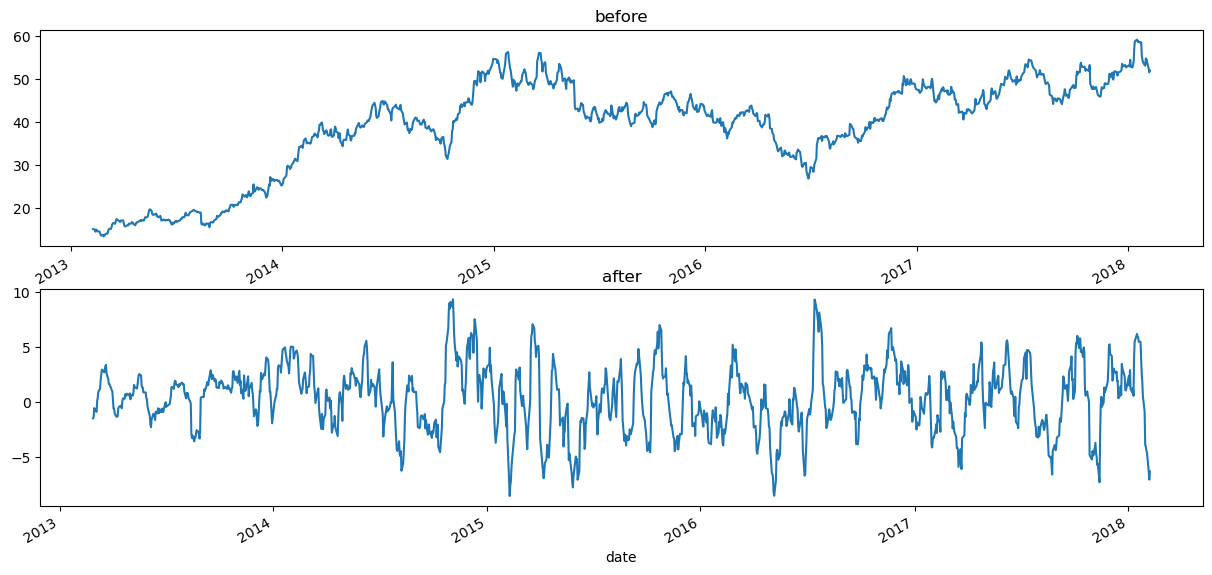

In [56]:
fig,ax = plt.subplots(nrows=2, figsize=(15,7))
AAL["high"].plot(ax=ax[0])
ax[0].set_title("before")
AAL["Seasonal Difference"].plot()
ax[1].set_title("after")

To perform the **ARIMA** we need to define 3 values which are:
* p=_AR model_
* d=_differencing_
* q=_MA model_

_AR model (Autoregressive) can be find by_ :**PACF**(Partial Autocorrelation Function)  
  
_MA model (Moving Average) can be find by_:**ACF**(Autocorrelation Function)

both are present in ```from statsmodels.graphics.tsaplots import plot_acf,plot_pacf```

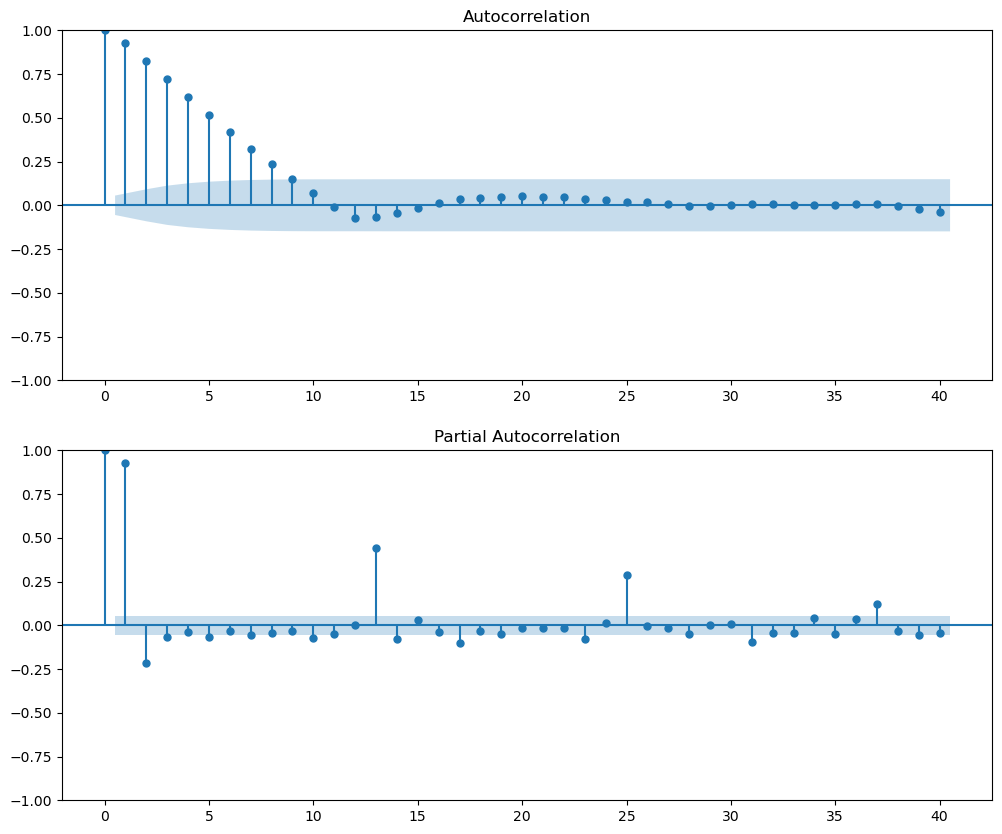

In [60]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(AAL["Seasonal Difference"].dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(AAL["Seasonal Difference"].dropna(),lags=40,ax=ax2)

**Hence:**  
|AR=3|   | MA=11| 
|---|----|-----|
|p=3| d=1| q=11|

In [74]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(AAL["Seasonal Difference"].dropna(),order=(6,1,11))
model_fit=model.fit()

C:\Users\updes\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\updes\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\updes\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\updes\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<h3 class="alert alert-block alert-success">SARIMA (Seasonal Autoregressive Integrated Moving Average)</h3>

<div class="alert alert-info">                  
<center><h1><b>UnsuperVised Learning</b></h1></center>
</div> 

<div class="alert alert-warning"><center><h2>Clustering</h2></center></div>

<h3 class="alert alert-block alert-success">K-Mean Clustering</h3>

In [155]:
data=pd.read_csv("iris.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [156]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["species"] = le.fit_transform(data["species"])
target=data.iloc[:,:-1]
target

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [157]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3)
km.fit(target)

KMeans(n_clusters=3)

In [158]:
km.predict(target)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [159]:
import warnings
warnings.filterwarnings('ignore')

# hypre peramater tuning by number of clusters
accuracy=[]
SSE=[]

from sklearn.metrics import accuracy_score
for i in range(1,11):
    km=KMeans(n_clusters=i)
    km.fit(target)
    accuracy.append(accuracy_score(data["species"], km.predict(target)))
    SSE.append(km.inertia_)

Text(0, 0.5, 'Accuracy')

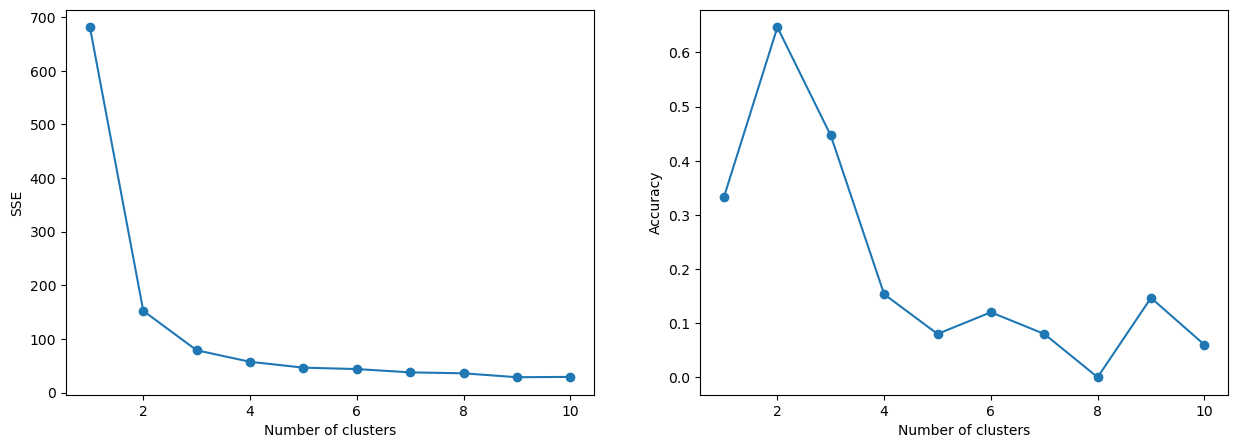

In [160]:
frame=pd.DataFrame({"clusters":range(1,11),"SSE":SSE,"Accuracy":accuracy})

figure,(ax1,ax2) = plt.subplots(ncols=2,figsize=(15,5))

ax1.plot(frame['clusters'], frame['SSE'], marker='o')
# plt.plot(frame["clusters"],frame["Accuracy"])
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('SSE')


ax2.plot(frame["clusters"],frame["Accuracy"], marker="o")
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Accuracy')

Text(0, 0.5, 'Accuracy')

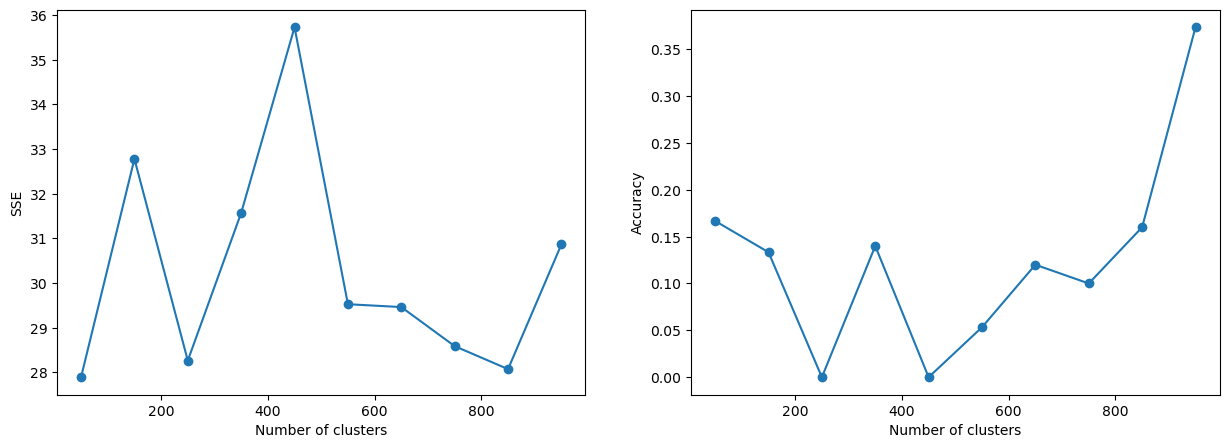

In [161]:
# hypre peramater tuning by number of clusters
accuracy=[]
SSE=[]

from sklearn.metrics import accuracy_score
for i in range(50,1000,100):
    km=KMeans(n_clusters=9,max_iter=i)
    km.fit(target)
    accuracy.append(accuracy_score(data["species"], km.predict(target)))
    SSE.append(km.inertia_)


frame=pd.DataFrame({"iteration":range(50,1000,100),"SSE":SSE,"Accuracy":accuracy})
figure,(ax1,ax2) = plt.subplots(ncols=2,figsize=(15,5))
ax1.plot(frame['iteration'], frame['SSE'], marker='o')
# plt.plot(frame["clusters"],frame["Accuracy"])
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('SSE')


ax2.plot(frame["iteration"],frame["Accuracy"], marker="o")
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Accuracy')

<h3 class="alert alert-block alert-success">Hierarchical Clustering</h3>

In [2]:
data=pd.read_csv("iris.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Let's encode and seperate the species column for further operations

In [3]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["species"] = le.fit_transform(data["species"])
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
x=data.iloc[:,:-1]
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


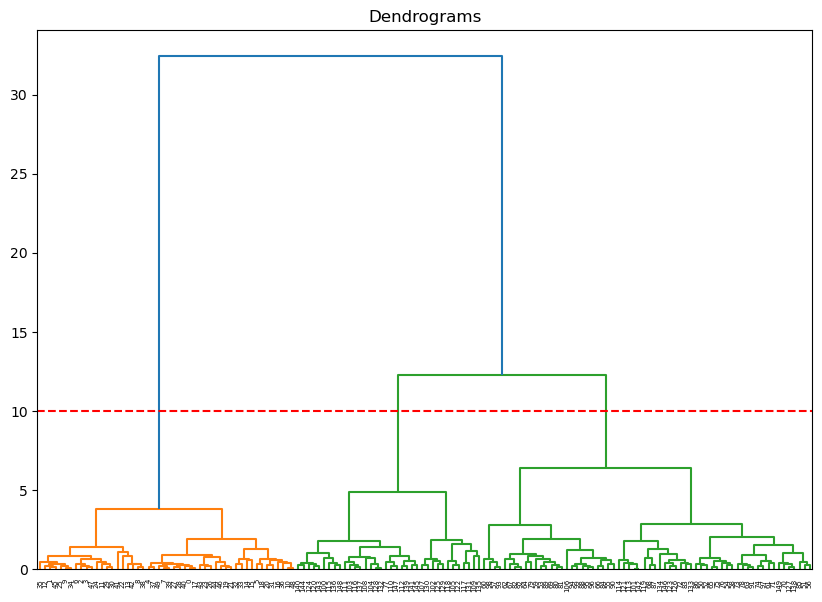

In [5]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  
dend = shc.dendrogram(shc.linkage(x, method='ward'))
plt.axhline(y=10, color='r', linestyle='--')

#### performing hierarchical clustering

In [6]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')  
ypred = cluster.fit_predict(x)
ypred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int64)

In [7]:
data["species"].values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
from sklearn.metrics import classification_report
matrix = classification_report(data["species"], ypred,labels=data["species"].unique())

print('Classification report of non scaled model : \n',matrix)

Classification report of non scaled model : 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.00      0.00      0.00        50
           2       0.97      0.70      0.81        50

    accuracy                           0.23       150
   macro avg       0.32      0.23      0.27       150
weighted avg       0.32      0.23      0.27       150



Text(0.5, 1.0, 'predicted cluster')

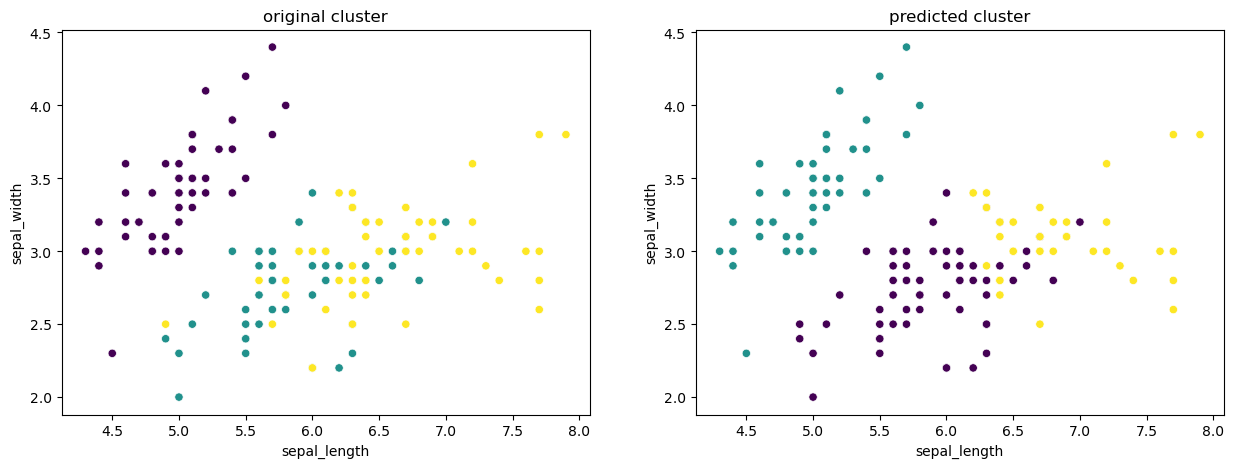

In [9]:
figure,(ax1,ax2)=plt.subplots(ncols=2,figsize=(15,5))
sns.scatterplot(x=data["sepal_length"],y=data["sepal_width"],c=data["species"],ax=ax1)
ax1.set_title("original cluster")

sns.scatterplot(x=data["sepal_length"],y=data["sepal_width"],c=ypred,ax=ax2)
ax2.set_title("predicted cluster")

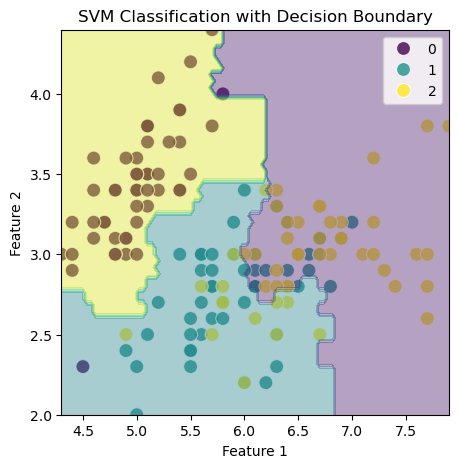

In [16]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=data["species"], palette='viridis', s=100, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Classification with Decision Boundary')

# Create a mesh to plot decision boundaries
x_min, x_max = x.iloc[:, 0].min() , x.iloc[:, 0].max()
y_min, y_max = x.iloc[:, 1].min() , x.iloc[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.04),
                     np.arange(y_min, y_max, 0.04))

# Create a 4-feature input array for prediction on the mesh grid
# The first two columns are the grid points, the last two are the mean values
input_features = np.c_[
    xx.ravel(),
    yy.ravel(),
]

# Predict class labels for each point in the mesh
Z = cluster.fit_predict(input_features)
Z = Z.reshape(xx.shape)

# Plot the decision boundary as a filled contour
plt.contourf(xx, yy, Z, alpha=0.4,)

plt.legend()
plt.show()

<div class="alert alert-warning"><center><h2>Association</h2></center></div>

<h3 class="alert alert-block alert-success">Apriori Algorithm</h3>

<div class="alert alert-warning"><center><h2>Dimensionality Reduction</h2></center></div>

<h3 class="alert alert-block alert-success">(PCA) Principal Component Analysis</h3>

In [21]:
from sklearn.preprocessing import LabelEncoder
data=pd.read_csv("sonar.all-data.csv")
le=LabelEncoder()
data.iloc[:,[-1]] = le.fit_transform(data.iloc[:,[-1]].values.ravel())
data.head()

,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,1
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,1


In [22]:
data.shape

(207, 61)

performing classfication useing knn without **PCA**

In [49]:
x=data.iloc[:,:-1]
y=data["R"].values
y=y.astype(int)

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x,y)

KNeighborsClassifier()

In [53]:
import time
start=time.time()
ypred=knn.predict(x)
print(time.time()-start)

from sklearn.metrics import accuracy_score
accuracy_score(y,ypred)

0.020791292190551758


0.8695652173913043

#### useing **PCA**

In [54]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x=ss.fit_transform(x)
x

array([[ 0.70018948,  0.42042142,  1.0529498 , ..., -0.4709383 ,
        -0.44268846, -0.42246083],
       [-0.13089402,  0.59942737,  1.71912994, ...,  1.30656071,
         0.25299833,  0.25405324],
       [-0.83579208, -0.64754631,  0.48045125, ..., -0.54822087,
        -0.63683361,  1.03005467],
       ...,
       [ 1.00042384,  0.15949749, -0.67235266, ...,  0.90469137,
        -0.0382194 , -0.68112798],
       [ 0.0475061 , -0.09535845,  0.13434985, ..., -0.00724291,
        -0.70154866, -0.34287094],
       [-0.13959647, -0.06501846, -0.78685237, ..., -0.67187297,
        -0.2970796 ,  0.99025973]])

In [55]:
from sklearn.decomposition import PCA
pca=PCA(n_components=50)
xtemp=pca.fit_transform(x)

print(f"shape after PCA ={xtemp.shape}")
# knn
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(xtemp,y)

import time
start=time.time()
ypred=knn.predict(xtemp)
print("time =",time.time()-start)

from sklearn.metrics import accuracy_score
print("accuracy =",accuracy_score(y,ypred))

shape after PCA =(207, 50)
time = 0.017277956008911133
accuracy = 0.9082125603864735


#### **hyperparameter tuning** of PCA

In [61]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.metrics import accuracy_score

timetaken=[]
accuracy=[]

for i in range(1,61,2):
    pca=PCA(n_components=i)
    xtemp=pca.fit_transform(x)

    # finging time 
    start = time.time()
    
    # traning knn
    knn=KNeighborsClassifier()
    knn.fit(xtemp,y)
    ypred=knn.predict(xtemp)

    net_time_taken = time.time()-start
    
    timetaken.append(net_time_taken)
    accuracy.append(accuracy_score(y,ypred))
    
    print(f"{i} feature \t TimeTaken = {net_time_taken} \t accuracy = {accuracy_score(y,ypred)}")

1 feature 	 TimeTaken = 0.010564327239990234 	 accuracy = 0.7294685990338164
3 feature 	 TimeTaken = 0.003520488739013672 	 accuracy = 0.821256038647343
5 feature 	 TimeTaken = 0.0022122859954833984 	 accuracy = 0.9178743961352657
7 feature 	 TimeTaken = 0.0 	 accuracy = 0.9082125603864735
9 feature 	 TimeTaken = 0.0 	 accuracy = 0.9178743961352657
11 feature 	 TimeTaken = 0.01670694351196289 	 accuracy = 0.9227053140096618
13 feature 	 TimeTaken = 0.023279428482055664 	 accuracy = 0.9227053140096618
15 feature 	 TimeTaken = 0.013002872467041016 	 accuracy = 0.9371980676328503
17 feature 	 TimeTaken = 0.013400793075561523 	 accuracy = 0.927536231884058
19 feature 	 TimeTaken = 0.00860738754272461 	 accuracy = 0.927536231884058
21 feature 	 TimeTaken = 0.015625953674316406 	 accuracy = 0.9227053140096618
23 feature 	 TimeTaken = 0.015625715255737305 	 accuracy = 0.9227053140096618
25 feature 	 TimeTaken = 0.015625715255737305 	 accuracy = 0.9178743961352657
27 feature 	 TimeTaken = 0.01

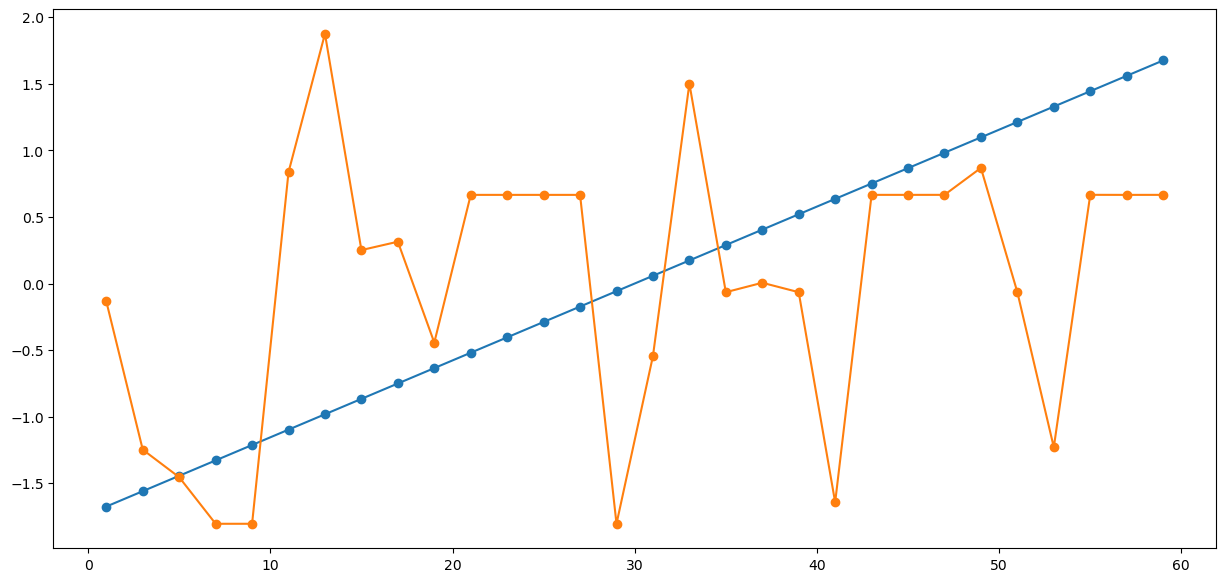

In [90]:
# graphical representation
frame = pd.DataFrame({"Features":range(1,61,2),"timetaken":timetaken,"accuracy":accuracy})
x_scaled=frame.iloc[:,:-1]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_scaled)
frame["timetaken"]=x_scaled[:,[0]]
frame["accuracy"]=x_scaled[:,[1]]

plt.figure(figsize = (15,7))
plt.plot(frame["Features"],frame["timetaken"],marker="o",)
plt.plot(frame["Features"],frame["accuracy"],marker="o")

<div class="alert alert-info">                  
<center><h1><b>Cheat Sheet</b></h1></center>
</div> 

```python
  
    from sklearn.linear_model import LinearRegression
    from sklearn.linear_model import LogisticRegression
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.api.sm.tsa.statespace import SARIMAX
    from sklearn.cluster import KMeans
    from sklearn.cluster import AgglomerativeClustering
    
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.preprocessing import LabelEncoder
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import MaxAbsScaler
    from sklearn.preprocessing import RobustScaler
    from sklearn.preprocessing import OrdinalEncoder
    
    from sklearn.metrics import r2_score
    from sklearn.metrics import classification_report
    from sklearn.metrics import accuracy_score

    from sklearn.model_selection import train_test_split
    from sklearn.model_selection import KFold

    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.over_sampling import SMOTE
    from imblearn.ensemble import BalancedRandomForestClassifier
    
    from statsmodels.tsa.stattools import adfuller
    from sklearn.decomposition import PCA
    from sklearn.impute import SimpleImputer
    from sklearn.impute import KNNImputer
    
    import time
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
```